# Depth Estimation

> Everything to know about predicting depth from images: relative vs metric depth, the mid-2026 model landscape, the scale-and-shift alignment that every benchmark number hides, and runnable code to test the leading open models.

- skip_showdoc: true
- skip_exec: true

## 1. What is Depth Estimation?

Depth estimation predicts, for every pixel of an image, **how far that surface is from the camera**. The learned flavour that dominates today is **monocular depth estimation**: one RGB image in, one depth map out - a problem that is *geometrically ill-posed* (a small nearby object and a large distant one project to identical pixels), so the model has to solve it with learned priors about how the world looks.

**Input.** A single RGB image, `H x W x 3`. Some models are resolution-sensitive: DPT-family models resize to a multiple of 14/32, Depth Pro always runs at 1536 x 1536, and prediction sharpness scales with input resolution.

**Output.** A single-channel map `H x W`, but *what the numbers mean* splits the whole field in two:

| Output type | Values | Ambiguity | Example models |
|-------------|--------|-----------|----------------|
| **Relative (affine-invariant) depth** | usually **inverse depth / disparity**, unitless: bigger = nearer | unknown **scale and shift** | Depth Anything V2, MiDaS/DPT, Marigold |
| **Metric (absolute) depth** | metres | none (in principle) | Depth Pro, ZoeDepth, UniDepth, DA V2-Metric |

That distinction is the single most important thing on this page. A relative model tells you the chair is nearer than the wall; it cannot tell you the chair is 1.4 m away, and you **cannot** recover metres from it without an external reference (a known object size, a LiDAR ping, camera intrinsics + a ground-plane assumption). If your downstream system measures, grasps, or brakes, you need a metric model - or a metric sensor.

**The non-learned alternatives** are still the accuracy leaders when you can afford them, and production stacks fuse them with monocular depth rather than replacing them:

- **Stereo** - two calibrated cameras; disparity gives metric depth from triangulation. Cheap, accurate near range, degrades on texture-less surfaces and at distance (error grows with depth squared).
- **Multi-view stereo / SfM** (COLMAP) - many views, offline, very accurate, needs camera motion and static scenes.
- **Active sensors** - structured light (Kinect v1, the sensor behind NYU Depth v2), time-of-flight (Kinect v2, phone dToF/"LiDAR" scanners), and rotating LiDAR (Velodyne, the sensor behind KITTI). Metric by construction, but sparse, power-hungry, short-range indoors (ToF), and blind on glass, mirrors, and dark or sunlit surfaces.

**Neighbouring tasks:**

| Task | What it does | Typical tool |
|------|--------------|--------------|
| Stereo matching | Disparity from a calibrated image pair | RAFT-Stereo, FoundationStereo |
| Multi-view geometry / pose | Depth + camera pose from N views | VGGT, MapAnything, Depth Anything 3, COLMAP |
| Depth completion | Dense metric depth from RGB + sparse LiDAR | Prompt Depth Anything |
| Surface normals | Per-pixel orientation (the depth gradient) | Marigold-Normals, DSINE |
| Image to 3D | Mesh / Gaussians from one image | see `15_Image_to_3D` |
| Segmentation | Which pixels belong to which object | see `03_Image_Segmentation` |
| Object detection | Boxes, often lifted to 3D using depth | see `02_Object_Detection` |

---

## 2. Real-World Use Cases

Depth is rarely the product. It is a **middle layer**: something else consumes it - a compositor, a planner, a generative model - and that consumer decides whether you need metres or merely order.

| Use case | Domain | Consumes / produces | Dominant constraint |
|----------|--------|---------------------|---------------------|
| Portrait bokeh, AR occlusion | Mobile consumer (iOS Portrait mode, ARKit/ARCore depth API) | Camera frame -> per-pixel depth for compositing virtual objects behind real ones | On-device latency and battery; temporal stability across frames; scale only matters relative to the subject |
| Driver assistance / autonomy | Automotive (Tesla occupancy networks, Mobileye) | Multi-camera rig -> metric depth / occupancy grid fused with radar | Metric accuracy at 50-150 m, hard latency budget, safety validation; monocular depth is a *prior*, never the sole sensor |
| Robot grasping and navigation | Warehouse / service robotics | RGB(-D) -> obstacle map, grasp poses | Millimetre-class metric accuracy at 0.3-1 m; a 5% scale error means a missed grasp |
| Drone obstacle avoidance | Aerial (Skydio) | Monocular / stereo video -> depth for path planning | Onboard compute, outdoor generalisation (sky, thin branches, wires) |
| Depth-conditioned generation | Generative AI (ControlNet-depth, ComfyUI, image-to-3D) | Image -> relative depth map used as a structural control signal | Boundary sharpness; absolute scale is irrelevant - this is why relative models dominate creative tooling |
| Photo and video editing | Creative software (Adobe 3D-aware effects, "3D photo" parallax) | Image -> relative depth -> relighting, dolly zoom, fake parallax | Detail on hair and thin structures; flicker-free across frames |
| Room scanning and measurement | Proptech / retail (RoomPlan, Zillow 3D, IKEA Place) | Phone RGB + ToF prompt -> metric floorplan | Metric accuracy that survives being fused across a walk-through |
| Endoscopy and surgical navigation | Healthcare | Endoscope video -> depth for 3D reconstruction | Extreme domain shift (specular, wet, non-Lambertian tissue), no ground truth to fine-tune on |
| Wildlife / crop measurement | Science and agriculture | Field photo -> object size in metres | Zero-shot metric accuracy with no calibration target in the shot |

**What the NYUv2 number hides.** Nearly every headline AbsRel is reported **after aligning the prediction to the ground truth** - median scaling for metric models, a least-squares scale *and shift* for relative ones (section 4). An aligned score answers "did the model get the *shape* of the scene right", not "can I trust these metres", so a model can top the leaderboard and still be useless in a robot cell. Then there is everything the metric averages away: **boundaries** (AbsRel is dominated by big flat walls, while the pixels you actually care about are the halo of wrong depth around a chair leg or a strand of hair), **ill-defined surfaces** (glass, mirrors, water, the sky - the ground truth itself is a hole there, so no metric penalises a wrong answer), and **temporal flicker** (a per-frame model re-guesses the global scale on every frame; the depth map jitters even when the camera is still, which is why video-specific models exist). Finally, **resolution is a deployment axis, not a detail**: Depth Pro's sharpness comes from running a 1536 x 1536 multi-scale pyramid, which is also why it costs ~10x a Depth Anything V2-Small forward pass.

---

## 3. How Modern Depth Estimation Works

The dated progression, each generation still alive somewhere:

1. **Geometry (pre-2014).** Stereo triangulation, SfM/MVS, shape-from-shading, plus active sensors. No learning, metric by construction, fails without texture or a second view.
2. **Supervised CNN regression (2014-2019).** Eigen et al. (2014) regress depth with a multi-scale CNN on NYUv2/KITTI; the **scale-invariant log loss (SILog)** appears here because absolute scale is unlearnable from a single dataset. Self-supervised variants (MonoDepth 2017, MonoDepth2 2019) train on stereo pairs or video with a photometric reprojection loss - no depth labels at all. All of them are **in-domain**: train on NYU, fail on the street.
3. **Mixed-dataset zero-shot relative depth: MiDaS (2019-2021).** Ranftl et al. train on a mix of incompatible depth sources (stereo movies, laser, ToF) using a **scale-and-shift-invariant loss in disparity space**. The model deliberately gives up metric scale in exchange for generalising to any image. **DPT (2021)** swaps the CNN for a ViT with a dense-prediction decoder; that DPT decoder is still the head on almost everything below.
4. **Metric heads on relative backbones: ZoeDepth (2023).** Pretrain relative (MiDaS-style), then bolt on an adaptive-bins metric head fine-tuned on NYU (indoor) and KITTI (outdoor). Metric, but only within the domains it was fine-tuned on.
5. **Foundation-scale relative depth: Depth Anything V1/V2 (2024).** DINOv2 encoder + DPT head, trained on ~600K *synthetic* labelled images with a large teacher pseudo-labelling **~62M unlabelled real images**. V2's key trick is that synthetic labels are pixel-perfect and never have sensor holes, so boundaries come out sharp; real data enters only as pseudo-labels for coverage. Still relative (inverse depth, affine-invariant).
6. **Camera-aware and zero-shot metric depth (2024-2025).** UniDepth and Metric3D v2 predict (or consume) camera intrinsics so metric scale becomes recoverable; **Depth Pro** (Apple, late 2024) predicts metric depth *and* the focal length in one shot, from a 1536 x 1536 multi-scale ViT pyramid fused by a DPT decoder - a 2.25 MP depth map in ~0.3 s on a server GPU, with the sharpest boundaries of the metric family. **Marigold** (2024) reframes depth as diffusion by fine-tuning Stable Diffusion 2 - beautiful detail, but many denoising steps (an LCM variant gets it to one).
7. **Prompted and multi-view geometry (2025).** **Prompt Depth Anything** takes a cheap LiDAR depth map as a *prompt* and outputs 4K metric depth. **MoGe-2** predicts metric point maps; **VGGT** (CVPR 2025) and **MapAnything** (Meta, 2025) do feed-forward multi-view geometry - depth, pose and intrinsics from N views in a single pass.
8. **The merge: Depth Anything 3 (Nov 2025).** ByteDance shows a **plain transformer** (a vanilla DINO encoder, no task-specific architecture) with a single **depth + ray** prediction target handles any number of views: monocular depth, multi-view depth, and camera pose in one model. It beats DA V2 on monocular depth and VGGT on multi-view, and is the mid-2026 accuracy reference - but it ships in its own `depth_anything_3` package, not in `transformers`.

**Mid-2026 status.** The task has effectively dissolved into "visual geometry foundation models" (depth + pose + intrinsics + point maps). For a *single image* on a 12 GB card and through `transformers` alone, the practical picks are unchanged: **Depth Anything V2** for relative depth, **Depth Pro** or **DA V2-Metric** for metres.

**Trade-off cheat sheet:**

| Approach | Output | Scale | Speed | Boundaries | Catch |
|----------|--------|-------|-------|------------|-------|
| Stereo / MVS (non-learned) | metric | absolute | fast (stereo) / slow (MVS) | good on texture | needs 2+ calibrated views |
| MiDaS / DPT | relative | unknown scale + shift | fast | soft | superseded by DA V2 |
| Depth Anything V2 | relative | unknown scale + shift | fastest (Small: 25M) | sharp | no metres |
| ZoeDepth | metric | absolute (in-domain) | medium | soft | degrades outside NYU/KITTI |
| DA V2-Metric | metric | absolute (indoor or outdoor variant) | fast | sharp | you must pick the right variant |
| Depth Pro | metric + focal length | absolute, zero-shot | slow (1536px pyramid) | sharpest | ~950M params, restrictive licence |
| Marigold (diffusion) | relative | unknown scale + shift | slow (multi-step) | very sharp | SD-sized, diffusers not transformers |
| Depth Anything 3 / VGGT | metric-ish + pose | absolute (DA3-metric) | medium | sharp | vendor package, not `transformers` |

---

## 4. Evaluation Metrics

Depth is scored per pixel against a sensor ground truth, on the **valid** pixels only (Kinect/LiDAR ground truth is full of holes, encoded as 0).

**Absolute Relative error (AbsRel)** - the headline metric. Relative, so a 10 cm error at 1 m counts as much as a 1 m error at 10 m:

$$AbsRel = \frac{1}{N}\sum_{i=1}^{N} \frac{|d_i - d_i^*|}{d_i^*}$$

**RMSE** - in metres, so it is dominated by the far field:

$$RMSE = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(d_i - d_i^*)^2}$$

**Threshold accuracy** ($\delta_1, \delta_2, \delta_3$) - the fraction of pixels whose ratio error is within $1.25^k$. Outlier-robust, and the metric to quote when you care about "is it broadly right everywhere":

$$\delta_k = \frac{1}{N}\left|\left\{ i : \max\left(\frac{d_i}{d_i^*}, \frac{d_i^*}{d_i}\right) < 1.25^k \right\}\right|$$

**SILog** (KITTI's official metric) removes a *global scale* factor before scoring, and boundary-focused metrics (Depth Pro introduced a boundary F1 score) exist precisely because AbsRel is dominated by large flat regions and says nothing about the halo of wrong depth around a chair leg.

### The pitfall: alignment comes first

**A relative model does not output metres, so scoring its raw output against a metre-valued ground truth is meaningless.** Depth Anything V2 outputs *inverse* depth (disparity-like, larger = nearer) with an unknown scale $s$ and shift $t$. The standard protocol - MiDaS's, and everyone's since - fits $(s, t)$ by **least squares in disparity space** against $1/d^*$, on the valid pixels of each image, and only then inverts back to depth and scores:

$$\hat{disp} = s \cdot disp_{pred} + t \quad\text{fitted so that}\quad \hat{disp} \approx 1/d^*$$

Metric models get the weaker **median scaling** treatment in many papers ($d \leftarrow d \cdot \mathrm{median}(d^*)/\mathrm{median}(d)$), which quietly erases exactly the property you bought a metric model for. Always ask a leaderboard row *which alignment it used*; an aligned AbsRel and a raw AbsRel are not comparable numbers.

Other pitfalls: mask out invalid ground truth (`gt > 0`), cap the range (10 m on NYU, 80 m on KITTI), and apply the **Eigen crop** on NYU (the outer border has no reliable Kinect returns) or your numbers will not match anyone's.

**Speed** is reported as ms/frame at a stated input resolution (depth cost scales with pixels, not with objects) and, for video, whether the model flickers frame to frame.

The cell below implements AbsRel / RMSE / $\delta_1$ and the scale-and-shift fit on a toy scene - no model needed - and shows what happens if you skip the alignment.

---

In [ ]:
import numpy as np

rng = np.random.default_rng(0)

# Toy ground truth: a 64x64 indoor-ish scene, 1 m (bottom) to 10 m (top), with a
# near object in the middle. Metres.
yy, xx = np.mgrid[0:64, 0:64]
gt = 10.0 - 9.0 * (yy / 63.0)
gt[24:44, 20:44] = 1.5

# What a RELATIVE model actually returns: inverse depth (disparity) under an
# unknown affine transform. s and t are properties of the model, not the scene -
# they are not recoverable from the image, and they change from image to image.
pred_disp = 3.7 * (1.0 / gt) + 0.42 + rng.normal(0, 0.005, gt.shape)

mask = (gt > 1e-3) & (gt < 10.0) & np.isfinite(gt)


def depth_metrics(pred, gt, m):
    "AbsRel, RMSE (m) and delta1 over the valid pixels m. Both inputs in metres."
    p, g = pred[m], gt[m]
    absrel = float(np.mean(np.abs(p - g) / g))
    rmse = float(np.sqrt(np.mean((p - g) ** 2)))
    ratio = np.maximum(p / g, g / p)
    return absrel, rmse, float(np.mean(ratio < 1.25))


def align_scale_shift(pred_disp, gt, m, eps=1e-6):
    "Least-squares fit s, t so that s * pred_disp + t ~ 1/gt. Returns depth in metres."
    m = m & np.isfinite(pred_disp)  # a NaN/Inf prediction pixel cannot constrain the fit
    if int(m.sum()) < 2:            # model overflowed (e.g. fp16 bins) - nothing to fit
        return np.full(gt.shape, np.nan, dtype=np.float32), float("nan"), float("nan")
    A = np.stack([pred_disp[m], np.ones(int(m.sum()))], axis=1)
    s, t = np.linalg.lstsq(A, 1.0 / gt[m], rcond=None)[0]
    return 1.0 / np.clip(s * pred_disp + t, eps, None), float(s), float(t)


# Wrong: score the network output as if it were metres.
print("raw disparity  AbsRel %.3f  RMSE %.3f m  delta1 %.3f" % depth_metrics(pred_disp, gt, mask))

# Right: fit (s, t) in disparity space, invert, then score.
aligned, s, t = align_scale_shift(pred_disp, gt, mask)
absrel, rmse, d1 = depth_metrics(aligned, gt, mask)
print(f"scale+shift    AbsRel {absrel:.3f}  RMSE {rmse:.3f} m  delta1 {d1:.3f}"
      f"   (fit s={s:.2f} t={t:.2f} - i.e. it inverted the model's 3.7 / 0.42 transform)")

# The half-measure: median scaling fixes the scale but never the shift. Even done
# properly (in disparity space, then inverted back to metres) it stays badly wrong,
# because the model's +0.42 offset is still in there.
scaled = pred_disp * (np.median(1.0 / gt[mask]) / np.median(pred_disp[mask]))
median_scaled = 1.0 / np.clip(scaled, 1e-6, None)
print("median-scaled  AbsRel %.3f  RMSE %.3f m  delta1 %.3f" % depth_metrics(median_scaled, gt, mask))

raw disparity  AbsRel 0.815  RMSE 4.989 m  delta1 0.057
scale+shift    AbsRel 0.005  RMSE 0.061 m  delta1 1.000   (fit s=0.27 t=-0.11 - i.e. it inverted the model's 3.7 / 0.42 transform)
median-scaled  AbsRel 0.193  RMSE 1.160 m  delta1 0.555


## 5. Datasets

Depth ground truth comes from a sensor, so every dataset inherits that sensor's failure modes: Kinect gives dense-but-noisy indoor depth with holes on glossy surfaces, LiDAR gives sparse accurate outdoor points with nothing above the horizon, and synthetic renders give perfect labels of a world that is not quite ours (which is exactly why Depth Anything V2 trains on them).

| Dataset | Contents | Size | Scope | License | Typical use |
|---------|----------|------|-------|---------|-------------|
| [NYU Depth v2](https://cs.nyu.edu/~fergus/datasets/nyu_depth_v2.html) ([HF re-upload](https://huggingface.co/datasets/jagennath-hari/nyuv2)) | RGB + Kinect depth, 464 indoor scenes | 1449 labelled pairs (407K raw frames); 654-image Eigen test split | Indoor, <= 10 m | MIT (re-upload) | **The** indoor eval benchmark; **used in this notebook** |
| [KITTI](https://www.cvlibs.net/datasets/kitti/) | Stereo car cameras + Velodyne LiDAR | 93K depth frames; 652-image Eigen split | Outdoor driving, <= 80 m | CC-BY-NC-SA | The outdoor eval benchmark |
| [DIODE](https://diode-dataset.org/) | High-res FARO laser scans, indoor *and* outdoor with one sensor | 25K train / 771 val | Both, 0.6-350 m | MIT | Zero-shot generalisation eval |
| [ETH3D](https://www.eth3d.net/) | Laser-scanned high-res multi-view | 25 scenes | Indoor + outdoor | CC-BY-NC-SA | Zero-shot metric eval (DA3 leads here) |
| [Hypersim](https://github.com/apple/ml-hypersim) | Photorealistic *synthetic* indoor renders, perfect dense depth | 77K images / 461 scenes | Indoor | CC-BY-SA / mixed | **Training** (DA V2-Metric-Indoor is fine-tuned on it) |
| [Virtual KITTI 2](https://europe.naverlabs.com/research/computer-vision/proxy-virtual-worlds-vkitti-2/) | Synthetic driving renders | 21K frames | Outdoor | CC-BY-NC-SA | Training (DA V2-Metric-Outdoor) |
| [Middlebury 2014](https://vision.middlebury.edu/stereo/data/) | Structured-light stereo pairs | 33 scenes | Indoor objects | Research-only | Stereo / high-precision disparity eval |
| [DA-2K](https://huggingface.co/datasets/depth-anything/DA-2K) | 1K images + 2K human-annotated **pairwise** "which point is nearer" labels, 8 scenarios (transparent, aerial, underwater...) | 1K images | Zero-shot, any domain | Apache 2.0 | Relative-depth eval where no sensor GT exists |

**This notebook evaluates on NYU Depth v2**, via the parquet re-upload `jagennath-hari/nyuv2` (uint16 millimetre depth maps, 145-image `test` split). The canonical HF copy (`sayakpaul/nyu_depth_v2`) is a *loading-script* dataset, and `datasets >= 4.0` dropped script support entirely - so it no longer loads. None of the datasets above are gated, but KITTI, ETH3D, Virtual KITTI and Middlebury are **non-commercial or research-only**; check before you train a product on them.

---

## 6. The Model Landscape (mid-2026)

There is no single official leaderboard for this task. The references are the Papers with Code tables for [monocular depth on NYU-Depth v2](https://paperswithcode.com/sota/monocular-depth-estimation-on-nyu-depth-v2) and [KITTI Eigen split](https://paperswithcode.com/sota/monocular-depth-estimation-on-kitti-eigen), plus [DA-2K](https://huggingface.co/datasets/depth-anything/DA-2K) for relative depth in the wild and the [Depth Anything 3](https://depth-anything-3.github.io/) visual-geometry benchmark for the 2026 state of the art.

| Model | Params | License | Scope | Architecture | Best for |
|-------|--------|---------|-------|--------------|----------|
| [Depth Anything V2-Small](https://huggingface.co/depth-anything/Depth-Anything-V2-Small-hf) | 24.8M | **Apache 2.0** | relative | DINOv2-S + DPT head | the default: fast, sharp, commercially usable |
| [Depth Anything V2-Base / Large](https://huggingface.co/depth-anything/Depth-Anything-V2-Large-hf) | 97.5M / 335M | **CC-BY-NC 4.0** | relative | DINOv2-B/L + DPT | best relative quality - *non-commercial only* |
| [DA V2-Metric-Indoor / Outdoor](https://huggingface.co/depth-anything/Depth-Anything-V2-Metric-Indoor-Base-hf) | 24.8M-335M | CC-BY-NC (B/L) | **metric** (20 m / 80 m cap) | DA V2 + metric head, fine-tuned on Hypersim / VKITTI2 | metres when you know indoor vs outdoor |
| [Depth Pro](https://huggingface.co/apple/DepthPro-hf) | 952M | apple-amlr (research) | **metric + focal length** | multi-scale ViT (DINOv2) pyramid @1536 + DPT fusion | zero-shot metres, sharpest boundaries, no intrinsics needed |
| [ZoeDepth](https://huggingface.co/Intel/zoedepth-nyu-kitti) | 345M | MIT | **metric** (NYU + KITTI) | BEiT/MiDaS encoder + metric bins head | permissively licensed metric baseline |
| [DPT-Large / MiDaS 3.1](https://huggingface.co/Intel/dpt-large) | 342M | Apache 2.0 | relative | ViT + DPT decoder | the historical baseline; still fine |
| [DPT-SwinV2-Tiny](https://huggingface.co/Intel/dpt-swinv2-tiny-256) | 41M | MIT | relative | Swin V2 + DPT | tiny CPU/edge relative depth |
| [GLPN-NYU](https://huggingface.co/vinvino02/glpn-nyu) | 61M | Apache 2.0 | metric (NYU only) | SegFormer encoder + light decoder | small in-domain indoor model |
| [Prompt Depth Anything](https://huggingface.co/depth-anything/prompt-depth-anything-vits-hf) | 25M | Apache 2.0 | **metric, LiDAR-prompted** | DA V2 + multi-scale prompt fusion | phone/robot with a cheap ToF sensor; 4K output |
| [Marigold Depth v1-1](https://huggingface.co/prs-eth/marigold-depth-v1-1) | ~1B (SD2) | OpenRAIL++ | relative | latent diffusion (SD2 fine-tune) | maximum detail when latency is free (`diffusers`) |
| [Depth Anything 3](https://huggingface.co/depth-anything/DA3-LARGE) | 34M (S) / 411M (L) / 1.36B (G) | Apache 2.0 (S), CC-BY-NC (L, G) | metric + camera pose, any number of views | plain DINO transformer, depth + ray target | **the mid-2026 SOTA** - needs the `depth_anything_3` package |
| UniDepth v2 / Metric3D v2 | ~300-700M | BSD / research | metric + intrinsics | camera-aware ViT | still the best raw NYUv2/KITTI *metric* numbers |
| VGGT / MapAnything / MoGe-2 | 0.3-1.3B | mixed | point maps + pose | feed-forward multi-view transformers | full geometry, not just depth |

**Who wins what.** *Accuracy:* Depth Anything 3 (and UniDepth v2 on the classic NYUv2/KITTI metric tables) - neither is `transformers`-native. *Metric accuracy through `transformers`:* Depth Pro, at ~950M params and a 1536px pyramid. *Speed and size:* DA V2-Small at 24.8M params, which is also the only DA V2 checkpoint under a commercial licence and the one that ships as CoreML/ONNX for phones. *Detail:* Marigold and Depth Pro.

Tie this back to section 2: the ControlNet/creative use cases want **DA V2-Small** (relative is fine, sharpness and speed matter); the robot and the measuring app want **Depth Pro** or a **prompted** model (metres, or metres plus a ToF prior); the phone wants the quantised Small model; and the car wants none of them alone.

**Fits a 12 GB card?** Everything in the runnable sections below does (Depth Pro is the heaviest at ~2 GB of fp16 weights plus a chunky 1536px activation footprint). The rows that do *not* belong in a runnable cell here are DA3-GIANT (1.36B, vendor package) and the multi-view point-map models, which want more VRAM and their own runtimes.

---

## 7. Setup

Everything below runs on one modest GPU (an RTX 3060, 12 GB) or on CPU, and **every runnable model loads through Hugging Face `transformers`** - all four families expose `AutoModelForDepthEstimation` and the `depth-estimation` pipeline, so the loading code is nearly identical between them. Package roles:

- `transformers` (>= 5.13) + `torch` - Depth Anything V2 (relative + metric), Depth Pro, ZoeDepth
- `accelerate` - device placement for the larger checkpoints
- `datasets` - the NYU Depth v2 eval split (RGB + uint16 mm depth), memory-mapped from parquet
- `numpy` + `pillow` - depth maps are arrays; the colourmap below is 12 lines of numpy (no matplotlib)
- `pyecharts` - the benchmark chart
- `pandas` - the benchmark table
- `opencv-python` - webcam capture in the optional real-time demo

Depth Anything 3, UniDepth, Metric3D and MoGe-2 need their own vendor packages and are **not** used in any runnable cell here. Marigold runs through `diffusers` (same HF ecosystem) - see section 14.

All downloads (sample image, HF model + dataset cache) land in `DL_tasks/datasets/`, which is gitignored.

---

In [ ]:
# Every runnable model here is transformers-native - no vendor depth packages.
# %pip install -q torch transformers datasets accelerate pillow pyecharts pandas

# Optional extra for the webcam demo (section 13)
# %pip install -q opencv-python

In [ ]:
import ctypes
import ctypes.util
import gc
import time
from pathlib import Path

import torch
from dotenv import find_dotenv, load_dotenv

# Knowledge/.env sets HF_TOKEN - authenticated HF Hub requests get higher rate limits
load_dotenv(find_dotenv(usecwd=True))

device = "cuda:0" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device != "cpu" else torch.float32
if device != "cpu":
    print(torch.cuda.get_device_name(0))
print("device:", device)

def vram(tag=""):
    "Report current GPU memory (allocated / reserved). No-op on CPU."
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        print(f"VRAM {tag:20s} {alloc:5.2f} GB allocated / {reserved:5.2f} GB reserved")

def free_memory():
    "Collect garbage, empty the CUDA cache, and return freed CPU RAM to the OS."
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    # glibc keeps freed CPU allocations in its arenas instead of returning them
    # to the OS, so RSS compounds across model sections (cpu-offloaded weights
    # live in system RAM). malloc_trim(0) hands the freed arenas back. See
    # dl-visualization-and-memory.instructions.md - not optional on a 12 GB box.
    try:
        ctypes.CDLL(ctypes.util.find_library("c") or "libc.so.6").malloc_trim(0)
    except Exception:
        pass

# All downloads go to DL_tasks/datasets/ (gitignored)
DATA_DIR = Path("../../datasets")
DATA_DIR.mkdir(exist_ok=True)
HF_CACHE = str(DATA_DIR / "hf_cache")

NVIDIA GeForce RTX 3060
device: cuda:0


sample image: (640, 480)   eval set: 145 NYU frames, gt (480, 640)
gt depth range: 0.89 - 9.96 m, 0.0% invalid (Kinect holes)


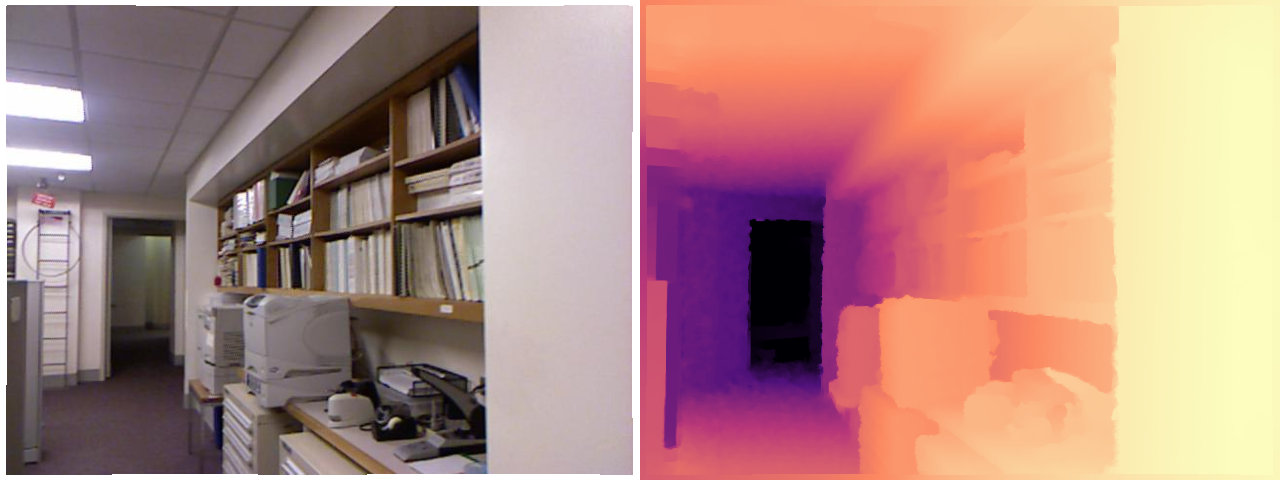

In [ ]:
import urllib.request

import numpy as np
from datasets import load_dataset
from PIL import Image

# A stable sample image (COCO val2017: two cats on a couch, with a clear
# near/far layout - remote controls up front, wall at the back).
SAMPLE = DATA_DIR / "coco_cats.jpg"
if not SAMPLE.exists():
    urllib.request.urlretrieve("http://images.cocodataset.org/val2017/000000039769.jpg", SAMPLE)
image = Image.open(SAMPLE).convert("RGB")

# Eval set: NYU Depth v2 test split (145 indoor RGB-D pairs, Kinect depth in mm).
# The canonical sayakpaul/nyu_depth_v2 copy is a loading-script dataset and no
# longer works on datasets >= 4.0, so we use the parquet re-upload.
nyu = load_dataset("jagennath-hari/nyuv2", split="test", cache_dir=HF_CACHE)
MAX_DEPTH = 10.0  # NYU evaluation cap, metres

def nyu_pair(row):
    "Return (RGB PIL image, ground-truth depth in metres as float32 HxW)."
    rgb = row["rgb"].convert("RGB")
    depth_m = np.asarray(row["depth"], dtype=np.float32) / 1000.0  # uint16 mm -> m
    return rgb, depth_m

# --- display helpers (ECharts cannot draw images; PIL can) --------------------
# A magma-like colourmap in pure numpy: bright = near, dark = far.
_STOPS = np.array([
    [0.00, 0, 0, 4],
    [0.25, 81, 18, 124],
    [0.50, 183, 55, 121],
    [0.75, 251, 136, 97],
    [1.00, 252, 253, 191],
], dtype=np.float32)

def colorize(depth, near_is_bright=True):
    "HxW float array (depth in m, or disparity) -> RGB PIL image, 2-98 pct stretched."
    d = np.asarray(depth, dtype=np.float32)
    finite = np.isfinite(d) & (d > 0)
    lo, hi = np.percentile(d[finite], [2, 98])
    x = np.clip((d - lo) / max(float(hi - lo), 1e-6), 0.0, 1.0)
    if not near_is_bright:  # metric depth: large value = far, so flip it
        x = 1.0 - x
    rgb = np.stack([np.interp(x, _STOPS[:, 0], _STOPS[:, i + 1]) for i in (0, 1, 2)], axis=-1)
    return Image.fromarray(rgb.astype("uint8"))

def side_by_side(*imgs):
    "Paste PIL images left-to-right at a common height."
    h = min(im.height for im in imgs)
    imgs = [im.convert("RGB").resize((int(im.width * h / im.height), h)) for im in imgs]
    canvas = Image.new("RGB", (sum(im.width for im in imgs), h))
    x = 0
    for im in imgs:
        canvas.paste(im, (x, 0))
        x += im.width
    return canvas

rgb0, gt0 = nyu_pair(nyu[0])
print(f"sample image: {image.size}   eval set: {len(nyu)} NYU frames, gt {gt0.shape}")
print(f"gt depth range: {gt0[gt0 > 0].min():.2f} - {gt0.max():.2f} m, "
      f"{(gt0 <= 0).mean():.1%} invalid (Kinect holes)")
side_by_side(rgb0, colorize(gt0, near_is_bright=False))

## 8. Depth Anything V2 (relative depth, the default)

`depth-anything/Depth-Anything-V2-Small-hf` - 24.8M params, Apache 2.0, DINOv2-S encoder with a DPT head. This is the model to reach for first: it runs in a few milliseconds, generalises to essentially any image, and is the one checkpoint of the family you can ship commercially (Base and Large are CC-BY-NC 4.0).

The `depth-estimation` pipeline returns a dict with `predicted_depth` (a tensor at the input resolution) and `depth` (a PIL preview). **Read the tensor, not the preview**: for the relative checkpoints the values are *inverse depth* - bigger means **nearer** - on an arbitrary affine scale that differs from image to image. Never feed those numbers to anything that expects metres (see section 4).

---

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

502 ms
shape: (480, 640)   range: 0.81 .. 5.16 (unitless)
VRAM DA V2-Small loaded    0.06 GB allocated /  0.24 GB reserved


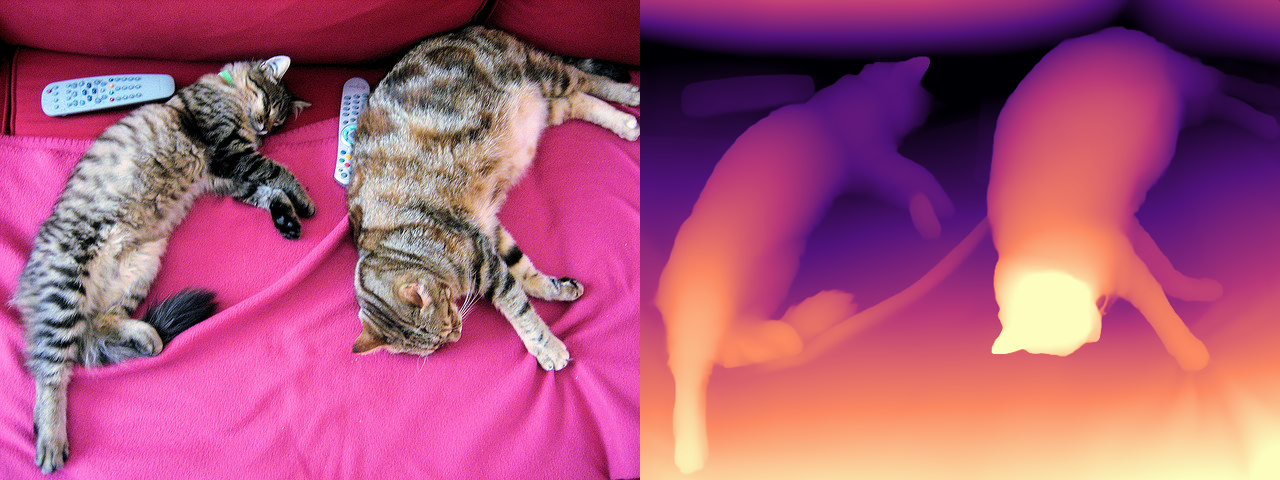

In [ ]:
from transformers import pipeline

da_pipe = pipeline(
    "depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=device,
    dtype=dtype,
    model_kwargs={"cache_dir": HF_CACHE},
)

t0 = time.perf_counter()
with torch.inference_mode():
    out = da_pipe(image)
print(f"{(time.perf_counter() - t0) * 1000:.0f} ms")

disp = out["predicted_depth"].float().cpu().numpy()  # inverse depth, arbitrary scale
print("shape:", disp.shape, "  range:", f"{disp.min():.2f} .. {disp.max():.2f} (unitless)")

vram("DA V2-Small loaded")
side_by_side(image, colorize(disp))  # bright = near

## 9. Depth Anything V2-Metric (metres, indoor)

`depth-anything/Depth-Anything-V2-Metric-Indoor-Base-hf` - the same DA V2 backbone with a metric head fine-tuned on **Hypersim** (synthetic indoor renders), capped at 20 m. An Outdoor sibling is fine-tuned on Virtual KITTI 2 and capped at 80 m.

This is the cheap way to get metres: pick the variant that matches your domain and the output is already in the right units. The cost is that *you* have to know the domain - run the indoor model on a street and the numbers are confidently wrong. Note the licence: Small is Apache 2.0, Base/Large inherit DA V2's CC-BY-NC 4.0.

Here we load it by hand (`AutoImageProcessor` + `AutoModelForDepthEstimation`) rather than through the pipeline, because that is the API you need whenever you want batching, `post_process_depth_estimation` control, or the extra outputs of section 10.

---

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

53 ms
predicted 0.54 .. 14.74 m (median 3.15 m)   ground truth median 2.35 m
raw AbsRel 0.433  RMSE 1.482 m  delta1 0.055
VRAM after DA V2-Metric    0.06 GB allocated /  0.08 GB reserved


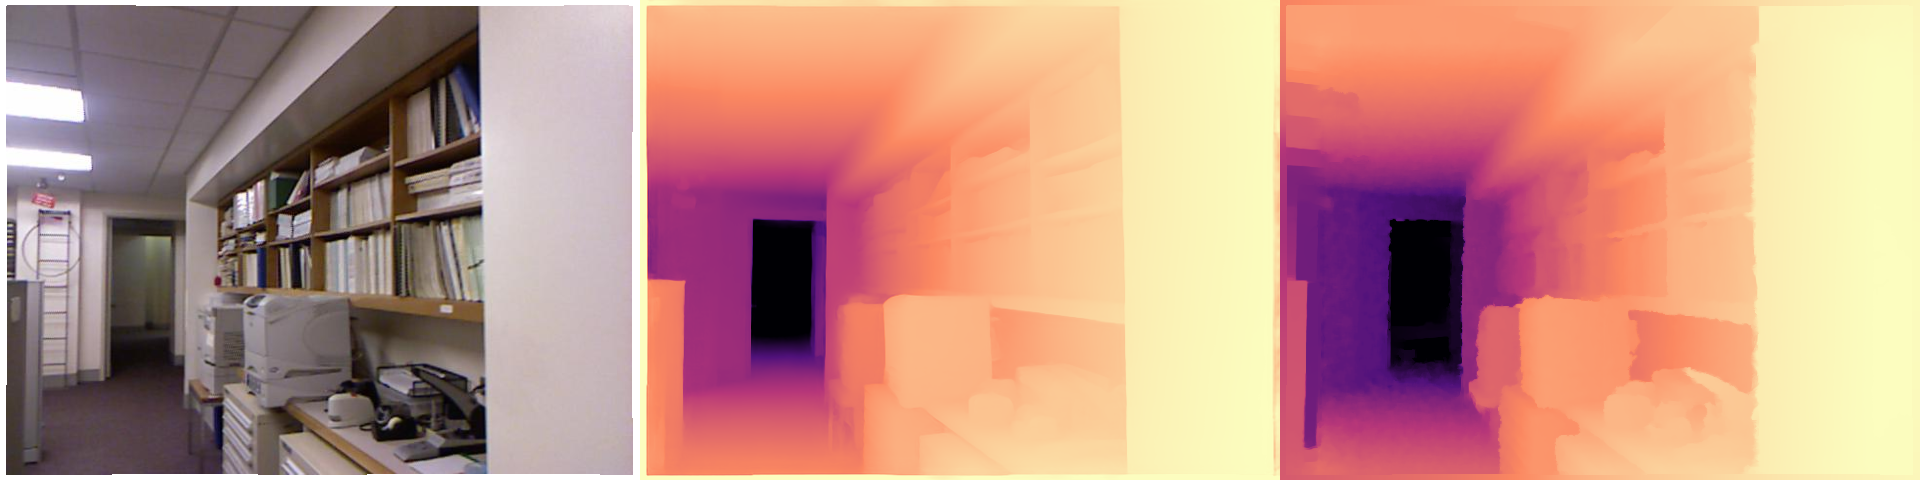

In [ ]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

metric_id = "depth-anything/Depth-Anything-V2-Metric-Indoor-Base-hf"
metric_proc = AutoImageProcessor.from_pretrained(metric_id, cache_dir=HF_CACHE)
metric_model = AutoModelForDepthEstimation.from_pretrained(
    metric_id, dtype=dtype, cache_dir=HF_CACHE
).to(device).eval()

rgb, gt = nyu_pair(nyu[0])  # an indoor NYU frame, so the indoor model is the right one
inputs = metric_proc(images=rgb, return_tensors="pt").to(metric_model.device, metric_model.dtype)

t0 = time.perf_counter()
with torch.inference_mode():
    outputs = metric_model(**inputs)
post = metric_proc.post_process_depth_estimation(outputs, target_sizes=[(rgb.height, rgb.width)])
pred_m = post[0]["predicted_depth"].float().cpu().numpy()
print(f"{(time.perf_counter() - t0) * 1000:.0f} ms")

m = (gt > 1e-3) & (gt < MAX_DEPTH)
print(f"predicted {pred_m[m].min():.2f} .. {pred_m[m].max():.2f} m "
      f"(median {np.median(pred_m[m]):.2f} m)   ground truth median {np.median(gt[m]):.2f} m")
print("raw AbsRel %.3f  RMSE %.3f m  delta1 %.3f" % depth_metrics(pred_m, gt, m))  # no alignment - real metres

del metric_model, metric_proc, outputs, inputs
free_memory()
vram("after DA V2-Metric")
side_by_side(rgb, colorize(pred_m, near_is_bright=False), colorize(gt, near_is_bright=False))

## 10. Depth Pro (zero-shot metric depth + focal length)

`apple/DepthPro-hf` - 952M params. Depth Pro predicts **metric depth without being told the camera intrinsics**, because it also predicts the horizontal field of view (and therefore the focal length) with a dedicated head. That is the piece that makes zero-shot metric depth possible on an arbitrary internet photo: metres and focal length are entangled, so a model that guesses one can commit to the other.

It runs a multi-scale patch pyramid at **1536 x 1536** regardless of your input size, which is where its boundary sharpness - and its cost, roughly 10x a DA V2-Small forward - comes from. In fp16 the weights are ~1.9 GB; with the 1536px activations, budget ~4-5 GB of VRAM. Pass `use_fov_model=False` to skip the FOV encoder and save memory when you only want the depth map.

**Licence warning:** `apple-amlr` is Apple's research licence, not an open-source one. Fine for experiments, read it before you ship.

---

Loading weights:   0%|          | 0/1407 [00:00<?, ?it/s]

951 ms
field of view: 47.2 deg   focal length: 731 px
metric depth: 0.72 .. 1.19 m
VRAM Depth Pro loaded      1.99 GB allocated /  6.10 GB reserved
VRAM after Depth Pro       0.06 GB allocated /  0.08 GB reserved


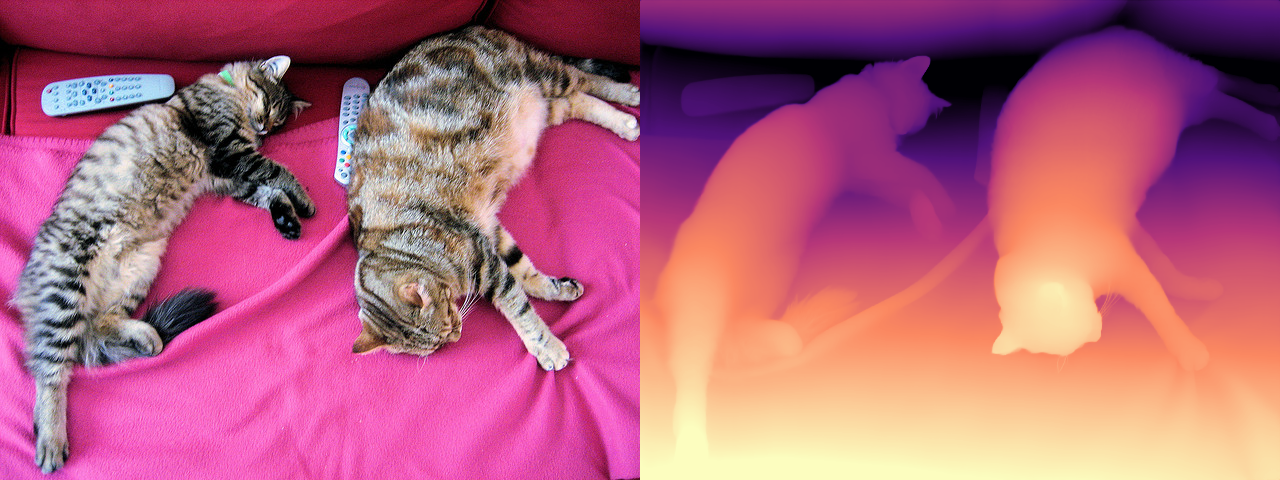

In [ ]:
from transformers import DepthProForDepthEstimation

dp_id = "apple/DepthPro-hf"
dp_proc = AutoImageProcessor.from_pretrained(dp_id, cache_dir=HF_CACHE)
dp_model = DepthProForDepthEstimation.from_pretrained(
    dp_id, dtype=dtype, cache_dir=HF_CACHE  # use_fov_model=False saves ~1 GB if you skip FOV
).to(device).eval()

inputs = dp_proc(images=image, return_tensors="pt").to(dp_model.device, dp_model.dtype)

t0 = time.perf_counter()
with torch.inference_mode():
    outputs = dp_model(**inputs)
post = dp_proc.post_process_depth_estimation(outputs, target_sizes=[(image.height, image.width)])
print(f"{(time.perf_counter() - t0) * 1000:.0f} ms")

dp_depth = post[0]["predicted_depth"].float().cpu().numpy()
print(f"field of view: {float(post[0]['field_of_view']):.1f} deg   "
      f"focal length: {float(post[0]['focal_length']):.0f} px")
print(f"metric depth: {dp_depth.min():.2f} .. {dp_depth.max():.2f} m")

vram("Depth Pro loaded")
depth_img = colorize(dp_depth, near_is_bright=False)

del dp_model, dp_proc, outputs, inputs, post
free_memory()
vram("after Depth Pro")
side_by_side(image, depth_img)

## 11. ZoeDepth (the permissively licensed metric baseline)

`Intel/zoedepth-nyu-kitti` - 345M params, **MIT**. The 2023 design that first made "relative pretraining + metric fine-tuning" work: a MiDaS/BEiT encoder, then an adaptive-bins metric head trained jointly on NYU (indoor) and KITTI (outdoor) with a router that picks the right head per image.

It is beaten on accuracy by both DA V2-Metric and Depth Pro, and it is soft on boundaries - but it is MIT-licensed, one checkpoint covers indoor *and* outdoor, and it is a good sanity baseline. Its image processor pads dynamically and does the flip-averaging trick from the paper, so its `post_process_depth_estimation` takes `source_sizes` (the *input* size to undo the padding), not `target_sizes` - a genuine API wart worth knowing.

---

Loading weights:   0%|          | 0/647 [00:00<?, ?it/s]

460 ms   metric depth 0.98 .. 10.25 m
raw AbsRel 0.176  RMSE 0.780 m  delta1 0.721
VRAM after ZoeDepth        0.06 GB allocated /  0.08 GB reserved


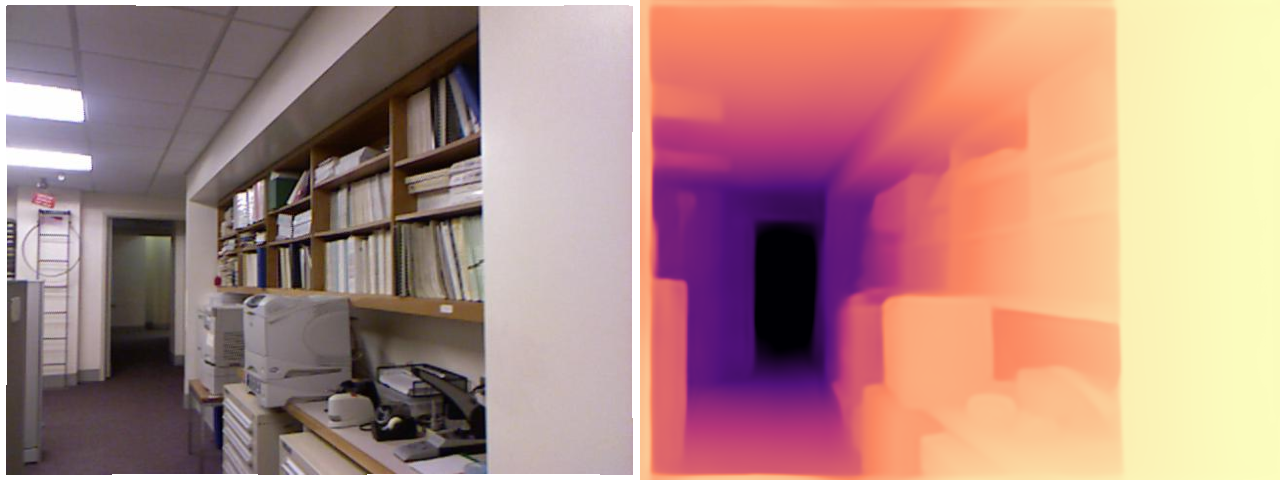

In [ ]:
zoe_id = "Intel/zoedepth-nyu-kitti"
zoe_proc = AutoImageProcessor.from_pretrained(zoe_id, cache_dir=HF_CACHE)
zoe_model = AutoModelForDepthEstimation.from_pretrained(
    zoe_id, dtype=dtype, cache_dir=HF_CACHE
).to(device).eval()

inputs = zoe_proc(images=rgb, return_tensors="pt").to(zoe_model.device, zoe_model.dtype)
 
t0 = time.perf_counter()
with torch.inference_mode():
    outputs = zoe_model(**inputs)
    # The paper averages the prediction with its horizontal flip; the processor
    # will do that for us if we hand it the flipped forward pass as well.
    outputs_flipped = zoe_model(pixel_values=torch.flip(inputs["pixel_values"], dims=[3]))
post = zoe_proc.post_process_depth_estimation(
    outputs,
    source_sizes=[(rgb.height, rgb.width)],  # NOT target_sizes - ZoeDepth pads dynamically
    outputs_flipped=outputs_flipped,
)
zoe_depth = post[0]["predicted_depth"].float().cpu().numpy()
print(f"{(time.perf_counter() - t0) * 1000:.0f} ms   "
      f"metric depth {zoe_depth.min():.2f} .. {zoe_depth.max():.2f} m")
print("raw AbsRel %.3f  RMSE %.3f m  delta1 %.3f" % depth_metrics(zoe_depth, gt, m))

del zoe_model, zoe_proc, outputs, outputs_flipped, inputs, post
free_memory()
vram("after ZoeDepth")
side_by_side(rgb, colorize(zoe_depth, near_is_bright=False))

## 12. Head-to-head Benchmark

Same images, same crop, same metrics, one model live at a time. The eval set is the first `N` frames of the **NYU Depth v2 test split** (indoor, Kinect ground truth, capped at 10 m, standard **Eigen crop**), on an RTX 3060 (12 GB).

Two AbsRel columns, and the gap between them is the whole point of section 4:

- **aligned** - a least-squares scale *and shift* fit in disparity space, per image. This is the only way to score a relative model, and it is what most published numbers use. Every model gets it, so the column is comparable.
- **raw** - the prediction taken literally as metres. Only defined for the metric models, and it is the number that tells you whether you can actually *use* the output. Expect it to be substantially worse than the aligned one; that difference is the metric error alignment hides.

Caveats: `N` frames of one indoor dataset is a **smoke test, not a leaderboard**. NYU is exactly the domain DA V2-Metric-Indoor and ZoeDepth were fine-tuned on, and it is out-of-domain for Depth Pro's zero-shot metric claim - so read the raw column as "how well does an in-domain fine-tune beat a generalist here", not "which model is best".

---

In [ ]:
N = 12  # eval frames (max 145). Depth Pro dominates the runtime: ~10x the others.

# Standard NYU Eigen crop: the outer border has no reliable Kinect returns.
def eigen_crop(a):
    return a[45:471, 41:601]

def valid_mask(gt):
    return (gt > 1e-3) & (gt < MAX_DEPTH) & np.isfinite(gt)

def score(pred, gt, kind, eps=1e-6):
    "Score one frame. kind: 'relative' (inverse depth) or 'metric' (metres)."
    pred, gt = eigen_crop(pred), eigen_crop(gt)
    m = valid_mask(gt) & np.isfinite(pred)  # drop pixels a model returned as NaN/Inf
    # Everything is aligned in DISPARITY space, so metric predictions are inverted first.
    disp = pred if kind == "relative" else 1.0 / np.clip(pred, eps, None)
    aligned, _, _ = align_scale_shift(disp, gt, m)
    ma = m & np.isfinite(aligned)
    nan3 = (float("nan"), float("nan"), float("nan"))
    a_absrel, a_rmse, a_d1 = depth_metrics(aligned, gt, ma) if int(ma.sum()) else nan3
    if kind == "metric":
        r_absrel, r_rmse, r_d1 = depth_metrics(np.clip(pred, 1e-3, None), gt, m) if int(m.sum()) else nan3
    else:
        r_absrel = r_rmse = r_d1 = float("nan")
    return dict(absrel_aligned=a_absrel, rmse_aligned=a_rmse, delta1_aligned=a_d1,
                absrel_raw=r_absrel, rmse_raw=r_rmse, delta1_raw=r_d1)

def to_hw(t, gt):
    "Model output -> float32 HxW array matching the ground-truth grid."
    a = t.float().cpu().numpy()
    a = a[0] if a.ndim == 3 else a
    if a.shape != gt.shape:  # bilinear resize in float ('F' mode) - no matplotlib needed
        a = np.asarray(Image.fromarray(a).resize((gt.shape[1], gt.shape[0]), Image.BILINEAR))
    return a

def benchmark(name, ckpt, kind, run_dtype=dtype, n=N):
    "Load ckpt, run it over n NYU frames, free it, and return the mean metrics."
    pipe = pipeline("depth-estimation", model=ckpt, device=device, dtype=run_dtype,
                    model_kwargs={"cache_dir": HF_CACHE})
    rows, elapsed = [], 0.0
    for i in range(n):
        rgb_i, gt_i = nyu_pair(nyu[i])
        t0 = time.perf_counter()
        with torch.inference_mode():
            out = pipe(rgb_i)
        elapsed += time.perf_counter() - t0
        rows.append(score(to_hw(out["predicted_depth"], gt_i), gt_i, kind))
    del pipe
    free_memory()
    res = {k: float(np.nanmean([r[k] for r in rows])) for k in rows[0]}
    res.update(model=name, kind=kind, ms_per_image=1000.0 * elapsed / n)
    print(f"{name:26s} AbsRel(aligned) {res['absrel_aligned']:.3f}  "
          f"delta1 {res['delta1_aligned']:.3f}  "
          f"AbsRel(raw) {res['absrel_raw']:.3f}  {res['ms_per_image']:6.0f} ms/img")
    return res

In [ ]:
# (name, checkpoint, kind, run_dtype). ZoeDepth's metric bin head is numerically
# unstable in fp16 (softmax over depth bins overflows to NaN on some frames), so it
# runs in fp32 - it is only 345M params and fits easily. Depth Pro stays fp16: it is
# stable but memory-heavy (~6 GB reserved), and fp32 would risk an OOM on 12 GB.
MODELS = [
    ("DAv2-Small",        "depth-anything/Depth-Anything-V2-Small-hf",                "relative", dtype),
    ("DAv2-Base",         "depth-anything/Depth-Anything-V2-Base-hf",                 "relative", dtype),
    ("DPT-Large (MiDaS)", "Intel/dpt-large",                                          "relative", dtype),
    ("DAv2-Metric-Indoor","depth-anything/Depth-Anything-V2-Metric-Indoor-Base-hf",   "metric",   dtype),
    ("ZoeDepth-nyu-kitti","Intel/zoedepth-nyu-kitti",                                 "metric",   torch.float32),
    ("Depth Pro",         "apple/DepthPro-hf",                                        "metric",   dtype),
]

results = [benchmark(*spec) for spec in MODELS]  # loads and frees one model at a time
vram("after benchmark")

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
/tmp/ipykernel_3000/347675089.py:49: RuntimeWarning: Mean of empty slice
  res = {k: float(np.nanmean([r[k] for r in rows])) for k in rows[0]}


DAv2-Small                 AbsRel(aligned) 0.057  delta1 0.973  AbsRel(raw) nan      32 ms/img


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

DAv2-Base                  AbsRel(aligned) 0.053  delta1 0.969  AbsRel(raw) nan      48 ms/img


...

DAv2-Metric-Indoor         AbsRel(aligned) 0.064  delta1 0.964  AbsRel(raw) 0.254      54 ms/img


Loading weights:   0%|          | 0/647 [00:00<?, ?it/s]

ZoeDepth-nyu-kitti         AbsRel(aligned) 0.041  delta1 0.985  AbsRel(raw) 0.128     207 ms/img


Loading weights:   0%|          | 0/1407 [00:00<?, ?it/s]

Depth Pro                  AbsRel(aligned) 0.050  delta1 0.974  AbsRel(raw) 0.075     949 ms/img
VRAM after benchmark       0.06 GB allocated /  0.08 GB reserved


In [ ]:
import pandas as pd

df = pd.DataFrame(results)[
    ["model", "kind", "absrel_aligned", "delta1_aligned", "rmse_aligned",
     "absrel_raw", "delta1_raw", "ms_per_image"]
].sort_values("absrel_aligned").reset_index(drop=True)
df.round(3)

,model,kind,absrel_aligned,delta1_aligned,rmse_aligned,absrel_raw,delta1_raw,ms_per_image
0,ZoeDepth-nyu-kitti,metric,0.041,0.985,0.198,0.128,0.923,206.939
1,Depth Pro,metric,0.050,0.974,0.258,0.075,0.966,949.132
2,DAv2-Base,relative,0.053,0.969,0.273,NaN,NaN,47.985
3,DAv2-Small,relative,0.057,0.973,0.260,NaN,NaN,31.869
4,DAv2-Metric-Indoor,metric,0.064,0.964,0.359,0.254,0.515,53.976
5,DPT-Large (MiDaS),relative,0.112,0.888,0.498,NaN,NaN,47.217


In [ ]:
from pyecharts import options as opts
from pyecharts.charts import Bar

names = [r["model"] for r in results]
bar = (
    Bar()
    .add_xaxis(names)
    .add_yaxis("AbsRel (scale+shift aligned)", [round(r["absrel_aligned"], 3) for r in results])
    .add_yaxis("AbsRel (raw metres)", [round(r["absrel_raw"], 3) if r["kind"] == "metric" else None
                                       for r in results])
    .set_global_opts(
        title_opts=opts.TitleOpts(title="NYU Depth v2 (Eigen crop)",
                                  subtitle=f"{N} frames, RTX 3060 - lower is better"),
        xaxis_opts=opts.AxisOpts(name="model", axislabel_opts=opts.LabelOpts(rotate=25)),
        yaxis_opts=opts.AxisOpts(name="AbsRel"),
        tooltip_opts=opts.TooltipOpts(trigger="axis"),
    )
)
bar.render_notebook()

In [ ]:
from pyecharts.charts import Scatter

# Accuracy vs speed: the engineering decision. Bottom-left is the sweet spot
# (low error, low latency). One series per model so the legend names the points.
xs = [f"{r['ms_per_image']:.0f}" for r in results]
scatter = Scatter().add_xaxis(xs)
for i, r in enumerate(results):
    ys = [None] * len(results)
    ys[i] = round(r["absrel_aligned"], 3)
    scatter.add_yaxis(r["model"], ys, symbol_size=16,
                      label_opts=opts.LabelOpts(is_show=False))
scatter.set_global_opts(
    title_opts=opts.TitleOpts(title="Accuracy vs speed", subtitle="NYU Depth v2, RTX 3060"),
    xaxis_opts=opts.AxisOpts(name="ms / image"),
    yaxis_opts=opts.AxisOpts(name="AbsRel (aligned)", type_="value"),
    tooltip_opts=opts.TooltipOpts(trigger="item"),
)
scatter.render_notebook()

## 13. Real-time Webcam Demo

Depth Anything V2-Small is small enough to run live (tens of ms per frame on a 3060, and it is the checkpoint Apple ships as CoreML for iPhones). This streams the camera through the pipeline and shows the raw frame next to its depth map as it happens.

Watch the status line, not just the picture: the depth map is **sharp but flickery**, and the 2-98 percentile disparity range printed each frame is that flicker made numeric. A per-frame relative model re-fits its own scale on every frame, so the range breathes even when nothing in the room moves. That is exactly what video-specific models (Video Depth Anything, DepthCrafter) exist to fix.

The view is **live**: the left pane is the raw camera, the right pane is the same
frame after the model, and both update in place through a display handle - no
`cv2.imshow`, no GUI, so it works over JupyterLab against a headless container. A
status line underneath carries the running FPS and the per-frame numbers. It runs
for `STREAM_SECONDS` seconds; interrupt the kernel to stop it early.

Two things throttle the frame rate before the model does, both measured on this
machine: **auto-exposure** drops the sensor to 15 FPS in a dim room (take exposure
off auto to pin 30), and setting `CAP_PROP_BUFFERSIZE` **halves** the delivered
rate on the V4L2 backend, so the helper deliberately does not set it.

Needs a real camera at `/dev/video0` - the cell raises rather than substituting
stand-in images. The docs builder never runs it (`skip_exec: true`).

---

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

VRAM DA V2-Small reloaded  0.06 GB allocated /  0.06 GB reserved


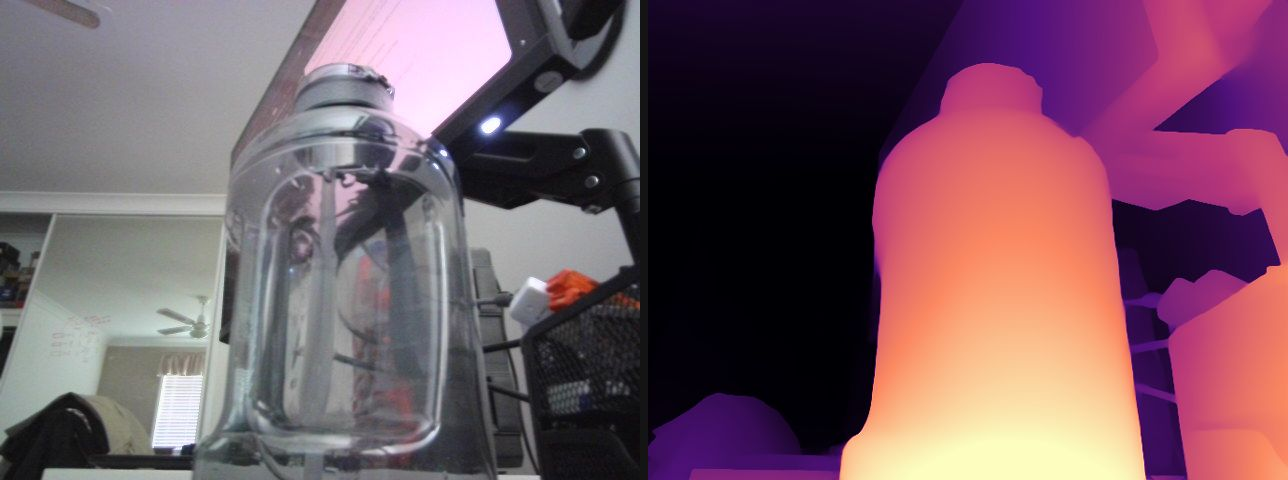

frame  167    11.1 FPS   model   38 ms   disparity 2-98 pct    0.00 ..    5.30

167 frames in 15.0s -> 11.1 FPS end-to-end (camera + model + JPEG encode)
VRAM final                 0.01 GB allocated /  0.02 GB reserved


In [ ]:
# opencv-python-headless is a project dependency; the headless build captures from
# V4L2 fine, it only drops the GUI windows.
import io
import time

import cv2
import numpy as np
import torch
from IPython.display import Image as IPyImage
from IPython.display import Pretty, display
from PIL import Image, ImageDraw, ImageFont

CAM = 0              # /dev/video0
WARMUP = 10          # throwaway reads - auto-exposure and white balance need to settle
STREAM_SECONDS = 15  # how long a live demo runs; interrupt the kernel to stop early


def bootstrap(*names, notebook, sections):
    """Make this demo runnable on a cold kernel, without duplicating the notebook.

    The demo builds on the notebook's setup and helper cells. Instead of making you
    run them by hand - or copying them in here and letting the copies drift - this
    reads the notebook file and executes those sections itself, and only when a name
    is actually missing. Run the notebook top to bottom and it does nothing at all.
    It stops as soon as every required name exists, so trailing benchmark cells in a
    section are not run.
    """
    if all(n in globals() for n in names):
        return
    import json
    from pathlib import Path

    from IPython.utils.capture import capture_output

    path = Path(notebook)
    if not path.exists():
        raise NameError(
            f"this demo needs {', '.join(n for n in names if n not in globals())}, and cannot "
            f"find {notebook} to bootstrap from (cwd is {Path.cwd()}, expected the notebook's "
            f"own directory). Run section(s) {'; '.join(sections)} by hand instead."
        )
    print(f"cold start: running {'; '.join(sections)} from {notebook} (output suppressed)")
    heading = None
    for cell in json.loads(path.read_text())["cells"]:
        src = "".join(cell["source"])
        if cell["cell_type"] == "markdown" and src.lstrip().startswith("## "):
            heading = src.lstrip().splitlines()[0][3:].strip()
            continue
        if cell["cell_type"] != "code" or not heading or "def bootstrap(" in src:
            continue
        if not any(heading.startswith(s) for s in sections):
            continue
        code = "".join("" if l.lstrip().startswith(("%", "!")) else l
                       for l in src.splitlines(keepends=True))
        # The setup cells print tables and display sample images. This demo only
        # wants the live stream, so swallow their output - errors still propagate.
        with capture_output():
            exec(compile(code, f"{notebook} [{heading}]", "exec"), globals())
        if all(n in globals() for n in names):
            break
    still = [n for n in names if n not in globals()]
    if still:
        raise NameError(f"bootstrapped {'; '.join(sections)} but {', '.join(still)} "
                        "are still undefined - the notebook layout may have changed.")


def open_camera(index=CAM, width=640, height=480, auto_exposure=True, exposure=150):
    "Open a V4L2 webcam in MJPEG mode, let it settle, and return the capture handle."
    cap = cv2.VideoCapture(index, cv2.CAP_V4L2)
    if not cap.isOpened():
        raise RuntimeError(
            f"/dev/video{index} did not open - no camera attached, "
            "or it is not passed through into this container"
        )
    cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter.fourcc(*"MJPG"))  # MJPEG unlocks the higher modes
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, width)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, height)
    # UVC exposure is DEVICE state and persists between processes: if anything left
    # this camera in manual mode, every frame comes back dark and never adapts
    # (measured here: mean 13/255 stuck, vs 109/255 on auto). So ask for the mode
    # explicitly instead of inheriting whatever the last program set.
    #   auto (3): correct brightness, but a dim room throttles the sensor to 15 FPS
    #   manual (1): locked 30 FPS, at whatever `exposure` level suits your lighting
    cap.set(cv2.CAP_PROP_AUTO_EXPOSURE, 3 if auto_exposure else 1)
    if not auto_exposure:
        cap.set(cv2.CAP_PROP_EXPOSURE, exposure)
    # Deliberately no CAP_PROP_BUFFERSIZE: on the V4L2 backend it HALVES the
    # delivered frame rate (measured here: 67 -> 134 ms per read) and does not make
    # frames any fresher.
    for _ in range(WARMUP):
        if not cap.read()[0]:
            cap.release()
            raise RuntimeError(f"/dev/video{index} opened but delivered no frames")
    return cap


def grab(cap):
    "Read one frame off an open camera as an RGB PIL image (OpenCV hands back BGR)."
    ok, frame = cap.read()
    if not ok:
        raise RuntimeError("failed to read a frame")
    return Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))


def capture_frame(**kw):
    "Open the camera, grab one settled frame, and release the device."
    cap = open_camera(**kw)
    try:
        return grab(cap)
    finally:
        cap.release()


_FONT = ImageFont.load_default(size=15)


def draw_lines(img, lines, pad=6):
    "Burn a few lines of text into a band across the top of a copy of `img`."
    out = img.convert("RGB").copy()
    d = ImageDraw.Draw(out)
    d.rectangle([0, 0, out.width, 18 * len(lines) + 2 * pad], fill=(0, 0, 0))
    for i, line in enumerate(lines):
        d.text((pad, pad + 18 * i), line, fill=(255, 255, 255), font=_FONT)
    return out


def pair_view(left, right, gap=8):
    "Raw frame and annotated frame side by side on one canvas - the live view."
    right = right.convert("RGB")
    if right.size != left.size:
        right = right.resize(left.size)
    canvas = Image.new("RGB", (left.width * 2 + gap, left.height), (20, 20, 20))
    canvas.paste(left.convert("RGB"), (0, 0))
    canvas.paste(right, (left.width + gap, 0))
    return canvas


def _jpeg(img, quality=80):
    "Encode a PIL image to JPEG bytes - what actually goes over the wire each frame."
    buf = io.BytesIO()
    img.convert("RGB").save(buf, format="JPEG", quality=quality)
    return buf.getvalue()


def live_stream(annotate, seconds=STREAM_SECONDS, width=640, height=480):
    """Stream `raw | annotated` into the notebook output until `seconds` elapse.

    `annotate(rgb)` returns `(annotated_image, info_string)`. The image and the
    status line each own a display handle and update in place, so this needs no GUI
    and no `cv2.imshow` - it works over JupyterLab against a headless container.
    Interrupt the kernel (the stop button) to end early; the camera is still released.
    """
    cap = open_camera(width=width, height=height)
    view = status = None  # created from the FIRST real frame, so no placeholder flashes up
    n, t0 = 0, time.perf_counter()
    try:
        while time.perf_counter() - t0 < seconds:
            rgb = grab(cap)
            annotated, info = annotate(rgb)
            n += 1
            frame = IPyImage(data=_jpeg(pair_view(rgb, annotated)))
            line = Pretty(f"frame {n:4d}   {n / (time.perf_counter() - t0):5.1f} FPS   {info}")
            if view is None:
                view = display(frame, display_id=True)
                status = display(line, display_id=True)
            else:
                view.update(frame)
                status.update(line)
    except KeyboardInterrupt:
        if status is not None:
            status.update(Pretty(f"stopped at frame {n}"))
    finally:
        cap.release()  # always hand the device back
    elapsed = time.perf_counter() - t0
    print(f"{n} frames in {elapsed:.1f}s -> {n / max(elapsed, 1e-9):.1f} FPS end-to-end "
          "(camera + model + JPEG encode)")


def preview(seconds=5, width=640, height=480):
    "Stream the raw camera so you can frame the shot, then return the final frame."
    cap = open_camera(width=width, height=height)
    view = status = None  # created from the FIRST real frame, so no placeholder flashes up
    last, n, t0 = None, 0, time.perf_counter()
    try:
        while time.perf_counter() - t0 < seconds:
            last = grab(cap)
            n += 1
            frame = IPyImage(data=_jpeg(last))
            line = Pretty(f"framing - {seconds - (time.perf_counter() - t0):4.1f}s left, "
                          f"{n} frames (the last one is the one that gets used)")
            if view is None:
                view = display(frame, display_id=True)
                status = display(line, display_id=True)
            else:
                view.update(frame)
                status.update(line)
    except KeyboardInterrupt:
        pass
    finally:
        cap.release()
    if status is not None:
        status.update(Pretty(f"captured the last of {n} frames"))
    return last


# Everything below builds on the notebook's setup and helper cells.
bootstrap("device", "dtype", "HF_CACHE", "colorize", "free_memory", "vram",
          notebook="00_Depth_Estimation.ipynb",
          sections=["7. Setup"])



# Section 8 leaves da_pipe live, but this cell frees it on its last line. Reload it
# when it is gone so the cell can be re-run on its own (weights are cached on disk).
if "da_pipe" not in globals():
    from transformers import pipeline

    da_pipe = pipeline(
        "depth-estimation",
        model="depth-anything/Depth-Anything-V2-Small-hf",
        device=device,
        dtype=dtype,
        model_kwargs={"cache_dir": HF_CACHE},
    )
    vram("DA V2-Small reloaded")


def annotate(rgb):
    "One frame -> (depth map image, the scale numbers that keep drifting)."
    t0 = time.perf_counter()
    with torch.inference_mode():
        out = da_pipe(rgb)
    depth = out["predicted_depth"].float().cpu().numpy()
    dt = (time.perf_counter() - t0) * 1000
    lo, hi = np.percentile(depth[np.isfinite(depth)], [2, 98])
    return colorize(depth), f"model {dt:4.0f} ms   disparity 2-98 pct {lo:7.2f} .. {hi:7.2f}"


live_stream(annotate)

# End of notebook - release the DA V2 pipeline we kept live since section 8.
del da_pipe
free_memory()
vram("final")

## 14. Going Further

- **Fine-tuning.** The HF [depth estimation fine-tuning guide](https://huggingface.co/docs/transformers/tasks/monocular_depth_estimation) covers the `AutoModelForDepthEstimation` + `labels` path. To make a relative model metric on *your* rig, do what DA V2-Metric did: keep the DINOv2 encoder frozen, swap in a metric head, fine-tune on a few thousand RGB-D frames from your own sensor. It is usually cheaper and far more accurate than fighting a generalist for absolute scale.
- **Sparse depth as a prompt.** If you have *any* real depth signal (phone ToF, a cheap 8x8 ToF chip, a few LiDAR returns), [Prompt Depth Anything](https://huggingface.co/depth-anything/prompt-depth-anything-vits-hf) fuses it into the decoder and returns 4K metric depth. This is `transformers`-native and beats every purely monocular model at metric accuracy - a reminder that the best fix for scale ambiguity is a sensor, not a bigger network.
- **Diffusion depth (`diffusers`).** [Marigold](https://huggingface.co/prs-eth/marigold-depth-v1-1) (`MarigoldDepthPipeline`) is the sharpest relative model, and the LCM variant runs in one step. Same HF ecosystem, different library.
- **Video / temporal consistency.** [Video Depth Anything](https://huggingface.co/spaces/depth-anything/Video-Depth-Anything) and [DepthCrafter](https://huggingface.co/tencent/DepthCrafter) add temporal attention so the scale stops breathing between frames. Per-frame models flicker; do not ship one into a video product without checking.
- **Models that still need a vendor runtime.** [Depth Anything 3](https://github.com/ByteDance-Seed/Depth-Anything-3) (`depth_anything_3` package - the mid-2026 SOTA, any-view depth + pose), [UniDepth v2](https://github.com/lpiccinelli-eth/UniDepth), [Metric3D v2](https://github.com/YvanYin/Metric3D), [MoGe-2](https://github.com/microsoft/MoGe), [VGGT](https://github.com/facebookresearch/vggt) and [MapAnything](https://github.com/facebookresearch/map-anything). None of them are in `transformers`; treat them as external runtimes.
- **Faster production runtimes (optional, external).** The same weights export cleanly: [DepthPro-ONNX](https://huggingface.co/onnx-community/DepthPro-ONNX), [CoreML Depth Anything V2-Small](https://huggingface.co/apple/coreml-depth-anything-v2-small) for iPhone, or TensorRT / OpenVINO for a server. Depth models are pure encoders - no autoregressive decode - so they quantise to int8 with little loss.
- **Downstream.** Depth feeds ControlNet-depth conditioning (see `04_Text_to_Image`), single-image 3D (see `15_Image_to_3D`), and 3D object detection (see `02_Object_Detection`); `03_Image_Segmentation` is the usual partner when you need "which object *and* how far".

**References**

- [Depth Anything V2 (Yang et al., NeurIPS 2024)](https://arxiv.org/abs/2406.09414) and the [DA-2K benchmark](https://huggingface.co/datasets/depth-anything/DA-2K)
- [Depth Anything 3 (ByteDance Seed, 2025)](https://arxiv.org/abs/2511.10647) and its [project page](https://depth-anything-3.github.io/)
- [Depth Pro: Sharp Monocular Metric Depth in Less Than a Second (Apple, 2024)](https://arxiv.org/abs/2410.02073)
- [MiDaS: Towards Robust Monocular Depth Estimation (Ranftl et al., 2020)](https://arxiv.org/abs/1907.01341) - the scale-and-shift-invariant loss
- [DPT: Vision Transformers for Dense Prediction (2021)](https://arxiv.org/abs/2103.13413)
- [ZoeDepth (Intel/ISL, 2023)](https://arxiv.org/abs/2302.12288)
- [Prompting Depth Anything for 4K Metric Depth (2024)](https://arxiv.org/abs/2412.14015)
- [HF transformers: monocular depth estimation task guide](https://huggingface.co/docs/transformers/tasks/monocular_depth_estimation) and the [depth-estimation task page](https://huggingface.co/tasks/depth-estimation)
- [Papers with Code: monocular depth estimation on NYU-Depth v2](https://paperswithcode.com/sota/monocular-depth-estimation-on-nyu-depth-v2)

---